# Capítulo 8 - Classificação de Imagem

## Introdução à ConvNets

**Exemplo simples de ConvNet:** o modelo usa uma ConvNet para classificar dígitos do MNIST, uma tarefa que realizamos no capítulo 2 usando uma rede densamente conectada (nossa precisão de teste na época foi de 97,8%). Mesmo que a ConvNet seja básica, sua precisão será muito superior à do modelo densamente conectado do capítulo 2.

### 8.1 Instanciando uma pequena ConvNet/

In [1]:
import keras
from keras import layers

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

É importante notar que uma ConvNet recebe como entrada tensores de formato (altura_da_imagem, largura_da_imagem,
canais_da_imagem) (sem incluir a dimensão do batch). Neste caso, configuraremos a
ConvNet para processar entradas de tamanho (28, 28, 1), que é o formato das imagens MNIST.

### 8.2 Exibindo o sumário do modelo

In [2]:
# O método .summary() pode ser usado para exibir a arquitetura da rede

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

Após a última camada `Conv2D`, terminamos com um output de forma (3, 3, 256) - um mapa de características 3x3 com 256 canais.

Em seguida, essa saída é passada para um classificador densamente conectado, como aqueles com os quais você já está familiarizado: uma pilha de camadas Dense. Esses classificadores
processam vetores, que são 1D, enquanto a saída atual é um tensor de rank-3. Para preencher essa lacuna, achatamos as saídas 3D para 1D com uma camada GlobalAveragePooling2D antes de adicionar as camadas Dense. Essa camada calculará a média de cada mapa de características 3×3 no tensor de formato (3, 3, 256), resultando em um vetor de saída de formato (256,)

### 8.3 Treinando a ConvNet com as imagens do MNIST

In [3]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 130s 137ms/step - accuracy: 0.9212 - loss: 0.2509
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 138ms/step - accuracy: 0.9791 - loss: 0.0684
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 133s 129ms/step - accuracy: 0.9858 - loss: 0.0471
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 122s 130ms/step - accuracy: 0.9894 - loss: 0.0347
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 118s 125ms/step - accuracy: 0.9912 - loss: 0.0284


### 8.4 Avaliando a ConvNet

In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9894 - loss: 0.0296
Test accuracy: 0.989


Enquanto o modelo densamente conectado tinha uma acurácia de 97.8%, a ConvNet básica tem uma precisão de teste de 98.9%, diminuímos a taxa de erro em cerca de 50%.

### 8.1.1 A operação de convolução

A diferença fundamental entre uma camada densamente conectada e uma camada de convolução é a seguinte: as camadas densas aprendem padrões globais em seu espaço de características de entrada (por exemplo, para um dígito do MNIST, padrões envolvendo pixels), enquanto uma camada de convolução aprende padrões locais, no caso de imagens, padrões encontrados em pequenas janelas 2D dos inputs. Essa característica fundamental confere à rede duas propriedades interessates:

- **Os padrões que aprendem são invariantes à translação**. Depois de aprender um determinado padrão no canto inferior direito de uma imagem, uma ConvNet pode reconhecê-lo em qualquer lugar: por exemplo, no canto superior esquerdo. Isso torna os ConvNets eficientes em termos de dados no processamento de imagens, já que o mundo visual é fundamentalmente invariante à translação. Eles precisam de menos amostras de treinamento para aprender representações que têm poder de generalização.

- Elas podem aprender **hierarquias espaciais de padrões**. Uma primeira camada de convolução aprenderá pequenos padrões locais, como bordas; uma segunda camada de convolução aprenderá padrões maiores, compostos pelas características das primeiras camadas; e assim por diante. Isso permite que as ConvNets aprendam com eficiência conceitos visuais cada vez mais complexos e abstratos, porque **o mundo visual é fundamentalmente hierárquico espacialmente.**

Convoluções são definidas por dois parâmetros principais:

- Tamanho dos patches extraídos dos inputs.

- Profundidade do mapa de características - O número de filtros computados por convolução. O exemplo anterior iniciou com uma profundidade de 64 canais e terminou com 256.

Uma convolução funciona deslizando janelas de tamanho 3×3 ou 5×5 sobre o mapa de características de entrada 3D, parando em cada localização possível e extraindo o patch 3D de
características circundantes de formato ((altura_da_janela, largura_da_janela, profundidade_de_entrada)). Cada patch 3D é então transformado em um vetor 1D de formato (profundidade_de_saída), o que é feito por meio de um produto tensorial com uma matriz de pesos aprendida, chamada kernel de convolução — o mesmo kernel é reutilizado em todos os patches. Todos esses vetores (um por patch) são então remontados espacialmente em um mapa de saída 3D de formato (altura, largura, profundidade_de_saída).

Observe que a largura e a altura da saída podem ser diferentes da largura e da altura da entrada. Isso pode ocorrer por dois motivos:
- Efeitos de borda, que podem ser atenuados com o preenchimento do mapa de recursos de entrada;
- O uso de strides (passos), que definiremos em seguida.

#### Entendo os efeitos de borda e o preenchimento

Considere um mapa de características de 5×5 (25 blocos no total). Existem apenas 9 blocos em torno dos quais você pode centralizar uma janela de 3×3, formando uma grade de 3×3. Portanto, o mapa de características resultante será de 3×3. Ele encolhe um pouco: exatamente dois blocos em cada dimensão, neste caso.

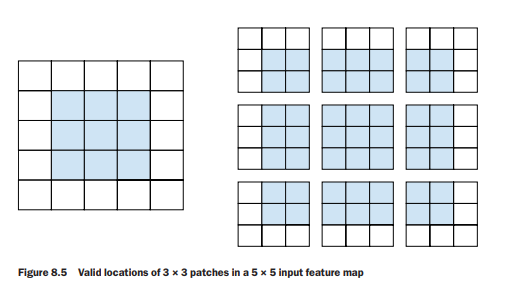

Se você deseja obter um mapa de características de saída com as mesmas dimensões espaciais da entrada, pode usar o preenchimento (padding). O preenchimento consiste em adicionar um número apropriado de linhas e colunas em cada lado do mapa de características de entrada, de forma a possibilitar o ajuste de janelas de convolução centradas em torno de cada bloco de entrada.


Nas camadas `Conv2D`, o preenchimento é configurável através do argumento `padding`, que aceita dois
valores: `valid`, que significa nenhum preenchimento (apenas locais de janela válidos serão usados);
e `same`, que significa "preencher de forma a ter uma saída com a mesma largura
e altura da entrada". O argumento `padding` tem como padrão o valor "valid".

Entendendo os strides da convolução

O outro fator que pode influenciar o tamanho do output são os strides. A descrição da convolução presupôs que os blocos centrais são todos contíguos. No entanto, a distância de duas janelas sucessivas é um parâmetro da convolução,denominado stride, que por padrão é 1.

É possível ter convoluções com stride: convoluções com um stride maior que 1. Na figura, é possível ver os patches extraídos por uma convolução 3x3 com stride igual a 2 sobre um input 5x5.



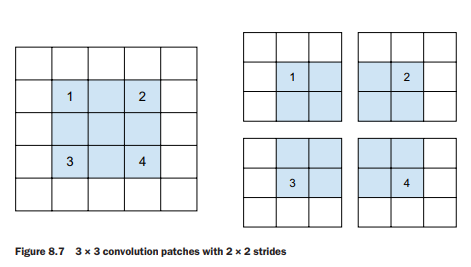

### 8.1.2 A operação de max-pooling

### 8.2 Treinando uma ConvNet a partir do zero com um dataset pequeno